# Demonstration of the preprocessing code

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

from load_dataset import CustomDatasetLoader
from image_duplicates import RemoveDuplicates
from blurred_images import RemoveBlurredFaces

In [41]:
MAX_DATA = 10000

emotion_map = {
    0: "angry",
    1: "disgust",
    2: "fear",
    3: "happy",
    4: "sad",
    5: "suprise",
}

loader = CustomDatasetLoader(csv_path="../format_datasets/dataset.csv", img_path="../format_datasets/dataset/")
images, labels = loader.load_dataset(max_samples=MAX_DATA)

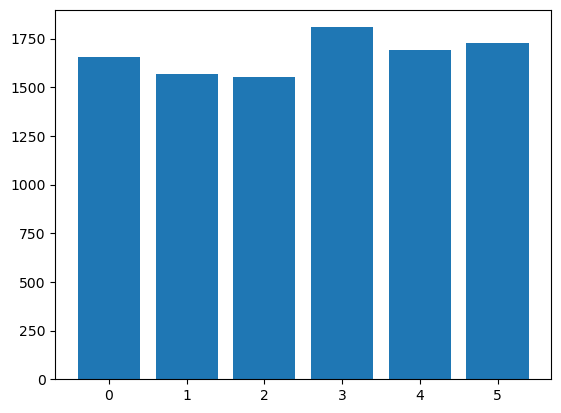

In [42]:
unique_labels, label_count = np.unique(labels, return_counts=True)
plt.bar(unique_labels, label_count)
plt.show()

## Blurry image removal

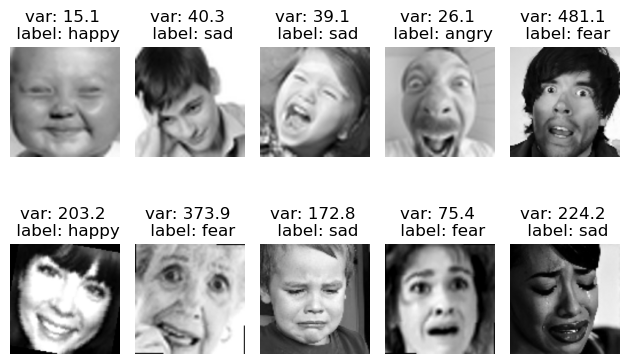

In [43]:
for i in range(10):
    image = images[i]
    label = labels[i]

    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

In [44]:
blur_handler = RemoveBlurredFaces()
sharp_images, proc_labels = blur_handler.process(images[:10], labels[:10], threshold = 200.0)

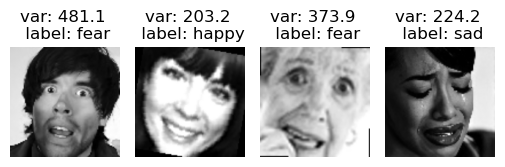

In [45]:
for i in range(len(sharp_images)):
    image = sharp_images[i]
    label = proc_labels[i]
    
    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

### Percentile overview

In [46]:
images_not_blurry, labels_not_blurry = blur_handler.process(images, labels, threshold = 200.0)

kept = images_not_blurry.shape[0]

print(f"kept {kept}/{MAX_DATA} ≈ {100 * kept/MAX_DATA:.2f}% (threshold = 200.0)")

images_not_blurry, labels_not_blurry = blur_handler.process(images, labels, threshold = 100.0)

kept = images_not_blurry.shape[0]

print(f"kept {kept}/{MAX_DATA} ≈ {100 * kept/MAX_DATA:.2f}% (threshold = 100.0)")

kept 4947/10000 ≈ 49.47% (threshold = 200.0)
kept 6507/10000 ≈ 65.07% (threshold = 100.0)


## Testing sharpening

In [47]:
sharpening_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

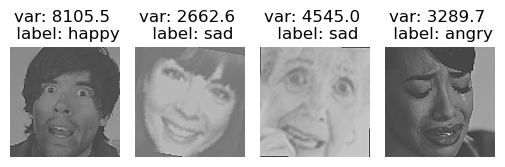

In [48]:
for i, image in enumerate(sharp_images):
    image = cv.filter2D(image, cv.CV_64F, kernel=sharpening_kernel)
    label = labels[i]
    
    variance = cv.Laplacian(image, cv.CV_64F).var()

    plt.tight_layout()
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"var: {variance:.1f} \n label: {emotion_map[label]}")
    ax.axis("off")


plt.show()

## Removing identical/similar images

In [49]:
chosen_images = [
    images[0],
    images[1],
    images[1],
    images[2],
    images[0],
]
chosen_images = np.array(chosen_images)

chosen_labels = [
    labels[0],
    labels[1],
    labels[1],
    labels[2],
    labels[0],
]
chosen_labels = np.array(chosen_labels)

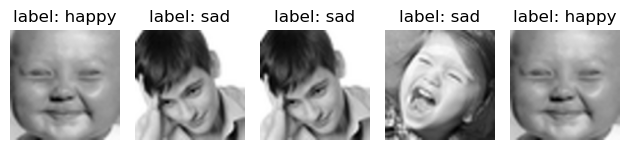

In [50]:

for i, image in enumerate(chosen_images):
    label = chosen_labels[i]

    plt.tight_layout()
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"label: {emotion_map[label]}")
    ax.axis("off")


plt.show()


In [51]:
duplicate_handler = RemoveDuplicates()
transformed_images, transformed_labels = duplicate_handler.process(chosen_images, chosen_labels)

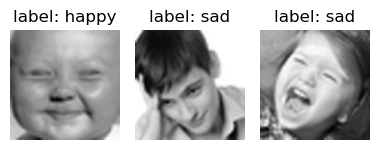

In [52]:
for i, image in enumerate(transformed_images):
    label = transformed_labels[i]

    plt.tight_layout()
    ax = plt.subplot(1, 5, i + 1)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"label: {emotion_map[label]}")
    ax.axis("off")


plt.show()
